# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [26]:
# importar librerías
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, chi2_contingency, ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [27]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

In [28]:
df_work = df.copy (deep = True)

**Vista previa e información general del conjunto de datos**

In [29]:
# mostrar las primeras 5 filas
df_work.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [30]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ Podemos ver que:
    - Hay 40,000 registros
    - No hay valores nulos
    - Hay dos variables que tienen tipo de datos incorrecto que son date y converted, pero solo date será cambiada a datetime ya que converted puede ser usada tal como esta
    

In [31]:
df_work["date"] = pd.to_datetime(df["date"])
df_work. info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [32]:
print(f"El número de usuarios únicos es: {df_work['user_id'].nunique()}")

El número de usuarios únicos es: 40000


 **Variable `date`**  
Explorar rango de fechas

In [33]:
# Resumen estadístico
df_work["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [34]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df_work["date"].min())
print("Fecha máxima:", df_work["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [35]:
# Resumen estadístico
df_work.describe().round (2)

,converted,gasto
count,40000.00,40000.00
mean,0.14,9.33
std,0.35,25.67
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,1.00,303.68


In [36]:

# Resumen estadístico de usuarios que se convirtieron

print (df_work[df_work["converted"] == 1]["gasto"].describe().round(2))
print ("resumen")
print ("#"*40)

columns = ["landing", "region", "dispositivo"]


for col in columns:
    
    print(df_work[df_work["converted"] == 1][col].value_counts(normalize=True))


    print ("#"*40)

   



count    5706.00
mean       65.37
std        30.90
min        12.12
25%        42.95
50%        59.86
75%        80.37
max       303.68
Name: gasto, dtype: float64
resumen
########################################
B    0.559762
A    0.440238
Name: landing, dtype: float64
########################################
Norte        0.286190
Centro       0.244655
Sur          0.194883
Occidente    0.159481
Oriente      0.114791
Name: region, dtype: float64
########################################
Mobile     0.571854
Desktop    0.428146
Name: dispositivo, dtype: float64
########################################


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [37]:

# Explorar variables categóricas y cómo se distribuyen

print("\nConteo de categorías:")
print ("#"*40)

categoricas = ["landing", "region", "dispositivo", "traffic_source", "user_type"]   

for col in categoricas:
    print(f"\n{col}:")
    print(df_work[col].value_counts())
    print ("#"*40)






Conteo de categorías:
########################################

landing:
B    20018
A    19982
Name: landing, dtype: int64
########################################

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64
########################################

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64
########################################

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64
########################################

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64
########################################


- Todas las columnas tienen valores esperados.
- El experimento esta bien balanceado aprox 20 mil casos en cada categoría A/B
- Las categorias no muestran errores o valores no esperados


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [38]:

# Gasto por versión

gasto_A = df_work[(df_work["landing"] == "A") & (df_work["converted"] == 1)]
gasto_B = df_work[(df_work["landing"] == "B") & (df_work["converted"] == 1)]

             

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)


(2512, 3194)

In [39]:
gasto_A = df_work[(df_work["landing"] == "A") & (df_work["converted"] == 1)]['gasto']
gasto_B = df_work[(df_work["landing"] == "B") & (df_work["converted"] == 1)]['gasto']
        

### Prueba T de Welch.

**Hipótesis:**
- **Hipótesis nula (H₀): No existe diferencia en el gasto promedio de los usuarios convertidos entre la versión A y la versión B.** 
- **Hipótesis alternativa (H₁): Sí existe diferencia en el gasto promedio entre ambas versiones.** 

In [40]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)


# Visualizar resultados

print(f"Estadístico t: {t_stat}")
print(f"Valor P: {p_value}")
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico t: -9.36563589591332
Valor P: 1.0635288333792346e-20
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la H0 (Hipótesis nula)

**Interpretación de negocio:**  
Existe evidencia estadísticamente significativa (p < 0.05) de que el gasto promedio de los usuarios convertidos difiere entre la versión A y la versión B de la página. Esto indica que el diseño de la landing page influye en el valor económico generado por cliente. La decisión final sobre qué versión implementar debe considerar cuál de las dos genera mayor gasto promedio, así como otras métricas clave como la tasa de conversión y el ingreso por usuario.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z-test.

**Hipótesis:**
- **Hipótesis nula (H₀): No existe diferecnia entre la tasa de conversión de los usuarios expuestos a diferentes paginas (A y B)** ...
- **Hipótesis alternativa (H₁): La tasa de conversión es diferente entre la versión A y la B.** ...

In [41]:
# Número de usuarios convertidos por página
conversiones = df_work[df_work["converted"] == 1].groupby("landing")["converted"].count()
# Total de usuarios por página
total_usuarios = df_work.groupby("landing")["converted"].count()


print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", total_usuarios)



Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [42]:
 #Obtener tasa o porcentaje de éxito
tasa_A = conversiones[0] / total_usuarios[0]
tasa_B = conversiones[1] / total_usuarios[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%)


In [43]:

z_stat, p_value = proportions_ztest(conversiones , total_usuarios)
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [44]:
df_work.groupby('landing')['converted'].mean()

landing
A    0.125713
B    0.159556
Name: converted, dtype: float64

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Existe evidencia estadísticamente significativa (p < 0.05) de que la tasa de conversión es diferente entre la versión A y la versión B. Al analizar las tasas de conversión vemos que la pagina B tiene una mayor tasa de conversión. Por lo tanto la versión B presenta una tasa de conversión significativamente mayor que la versión A (15.96% vs 12.57%), y esta diferencia es estadísticamente significativa (p < 0.05). **Esto indica que la versión B es más efectiva para convertir usuarios en clientes.**

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):La conversión es independiente de la fuente de tráfico.** ...
- **Hipótesis alternativa (H₁): La conversión depende de la fuente de tráfico.** ...

In [45]:
# Construir  tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)

# Ejecutar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

print() #salto de línea
# Tabla de contingencia normalizada
print((pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100).round(2))


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la Hipótesis nula

**Interpretación de negocio:**  
Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0.034).
Los canales de Email y Ads presentan mayores tasas de conversión en comparación con Organic y Referral, lo que sugiere que los usuarios provenientes de estos canales tienen una mayor intención de compra.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [46]:
# Construir  tabla de contingencia
tabla = pd.crosstab(df['user_type'], df['converted'])
print(tabla)

# Ejecutar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

print() #salto de línea
# Tabla de contingencia normalizada
print((pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100).round(2))

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.

converted       0      1
user_type               
Nuevo       85.64  14.36
Recurrente  85.91  14.09


### 📝 Conclusión e interpretación

**Decisión:**  
Se corrobora la hipótesis nula

**Interpretación de negocio:**  
No se encontró evidencia estadísticamente significativa de asociación entre el tipo de usuario y la conversión (p = 0.474). La conversión es consistente entre usuarios nuevos y recurrentes, lo que sugiere que la efectividad de la landing page es homogénea independientemente del historial del usuario.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

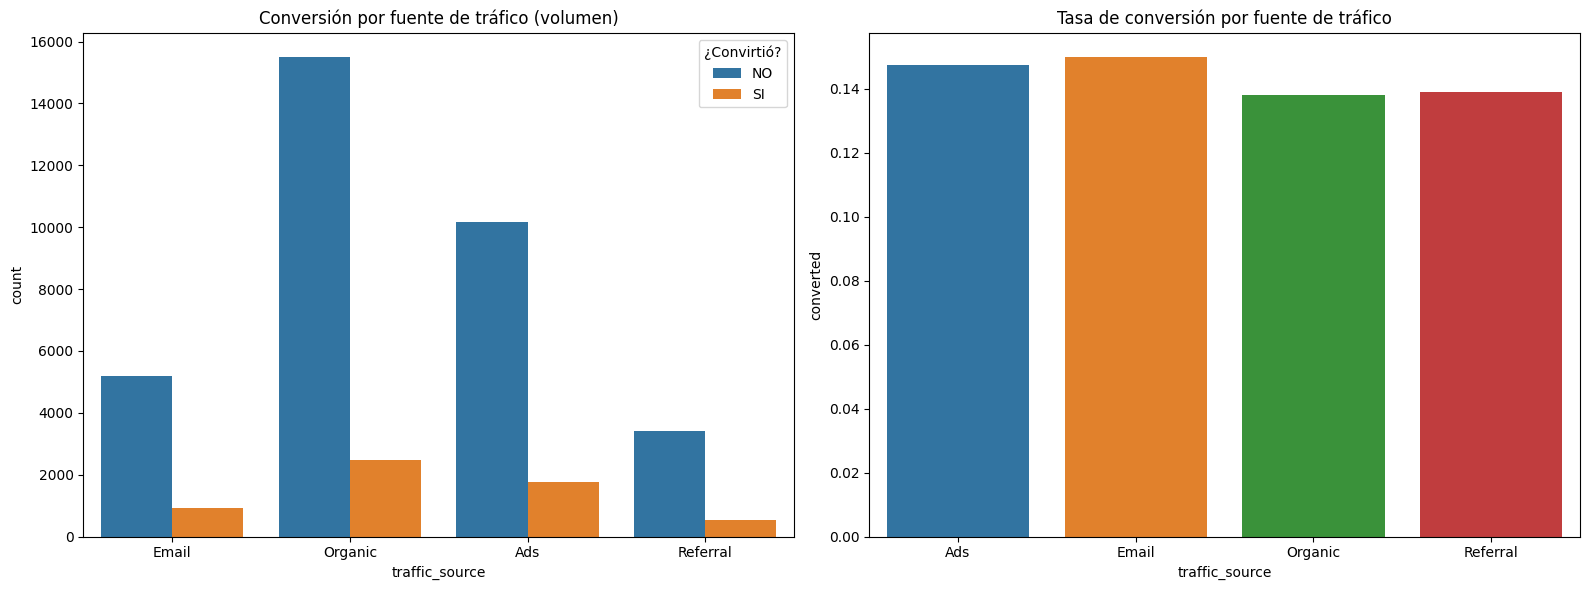

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_work, x='traffic_source', hue='converted', ax=axes[0])
axes[0].set_title('Conversión por fuente de tráfico (volumen)')
axes[0].legend(title='¿Convirtió?', labels=['NO', 'SI'])


conversion_rates = df_work.groupby('traffic_source')['converted'].mean().reset_index()
sns.barplot(data=conversion_rates, x='traffic_source', y='converted', ax=axes[1])
axes[1].set_title('Tasa de conversión por fuente de tráfico')

plt.tight_layout()
plt.show()

✍️ **Comentario**:
En la grafica de Conversión por fuente de trafico vemos que Organic concentra el mayor volumen de usuarios y, en consecuencia, el mayor número absoluto de conversiones. Sin embargo, esto se debe principalmente al volumen de tráfico y no necesariamente a una mayor eficiencia del canal.
Mientras que en la gráfica de tasa de conversión se observa que los canales de Email y Ads presentan las tasas de conversión más altas, superando a Organic y Referral, lo que indica una mayor efectividad en la conversión de usuarios.

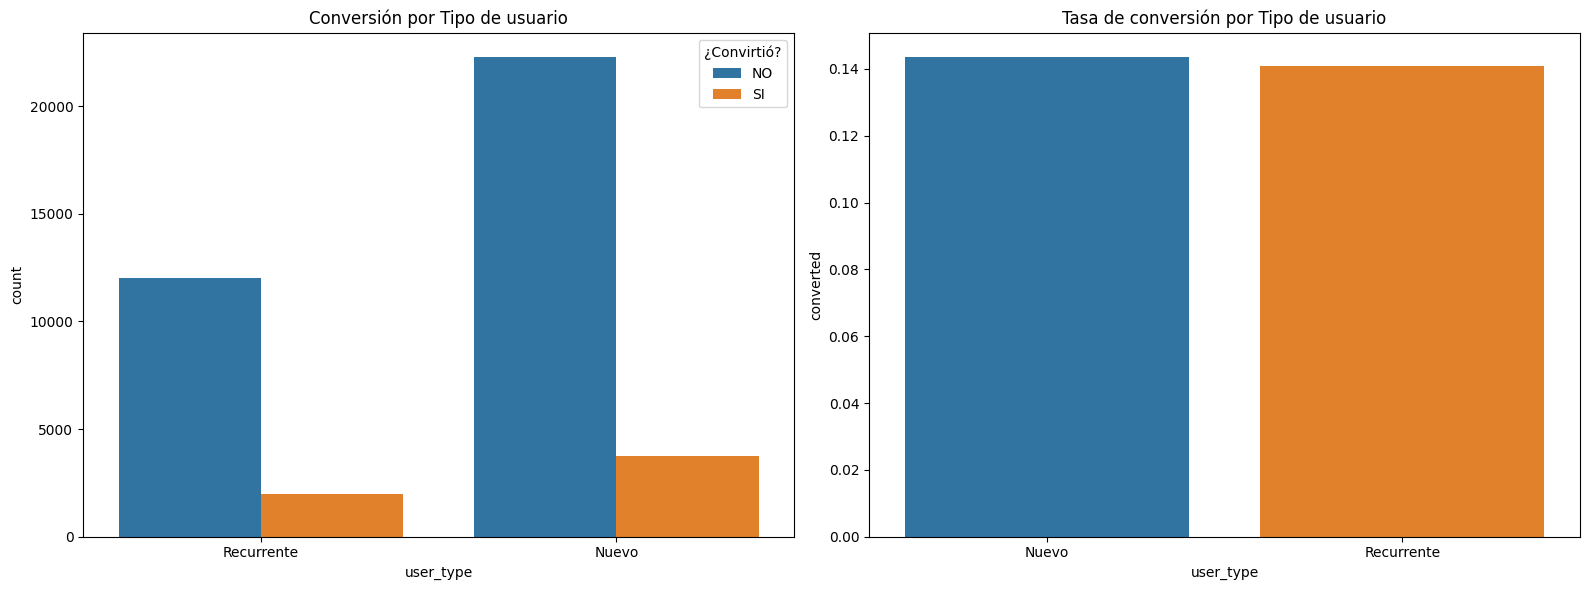

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_work, x='user_type', hue='converted', ax=axes[0])
axes[0].set_title('Conversión por Tipo de usuario')
axes[0].legend(title='¿Convirtió?', labels=['NO', 'SI'])


conversion_rates = df_work.groupby('user_type')['converted'].mean().reset_index()
sns.barplot(data=conversion_rates, x='user_type', y='converted', ax=axes[1])
axes[1].set_title('Tasa de conversión por Tipo de usuario')

plt.tight_layout()
plt.show()



✍️ **Comentario**: En la gráfica de Conversión por tipo de usuario podemos observar que los usuarios nuevos representan la mayor parte del tráfico y, en consecuencia, generan la mayor cantidad absoluta de conversiones. Mienstras que en la grafica de la tasa de conversión  se puede observar que las tasas de conversión entre usuarios nuevos y recurrentes son muy similares, sin diferencias relevantes en términos de efectividad.

La estrategia de conversión no requiere diferenciación entre usuarios nuevos y recurrentes, ya que ambos responden de manera similar a la página.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

- Existe una diferencia estadísticamente significativa en el gasto promedio entre los usuarios que convirtieron en la página A y la página B (p < 0.05).
- Esto indica que el diseño de la landing page influye directamente en el valor económico generado por cliente.


- **Interpretación:**
La versión de la página impacta no solo la conversión, sino también el comportamiento de compra de los usuarios, lo que puede traducirse en diferencias relevantes en ingresos.
<br>

**Tasa de conversión:** 
- La página B presenta una tasa de conversión mayor (15.96%) en comparación con la página A (12.57%).
- Esta diferencia es estadísticamente significativa (p < 0.05), lo que confirma que no es producto del azar.
- **Interpretación:**
La versión B es más efectiva para convertir usuarios en clientes, lo que la posiciona como la mejor opción desde el punto de vista de adquisición.
---

#### 📊 **Segmentación por fuente de tráfico**

- Los canales de Email y Ads presentan mayores tasas de conversión en comparación con Organic y Referral, aunque Organic concentra el mayor volumen de usuarios.
- 
- **Interpretación:**
Existe una diferencia entre volumen y eficiencia:

- Organic aporta escala
- Email y Ads aportan mayor calidad de tráfico (mejor conversión)

*Esto sugiere que no todos los canales contribuyen de la misma forma al desempeño del negocio.*


 
 ---

#### 📊 **Segmentación por tipo de usuario**

- No se encontraron diferencias significativas en la tasa de conversión entre usuarios nuevos y recurrentes (p > 0.05), presentando ambos comportamientos muy similares (~14%).


- **Interpretación:**
El tipo de usuario no influye de manera relevante en la probabilidad de conversión, lo que indica que la landing page tiene un desempeño consistente independientemente del historial del usuario.


---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Recomendación 1:

Implementar la versión B de la página de inicio, ya que mejora significativamente la tasa de conversión y tiene impacto en el valor económico por usuario.

- Recomendación 2:

Optimizar la inversión en canales de alto rendimiento como Email y Ads, priorizando estos sobre canales de menor conversión como Organic y Referral, sin descuidar el volumen que estos últimos aportan.


